# Solução do Desafio 1 - Heart Disease : Pedro Vale De Souza - 231038733
### Dataset: Heart Disease UCI Dataset
#### Atributos e tipagem
- Idade: Inteiro

- Gênero: Booleano - (1=masculino, 0=feminino)

- Tipo de dor no peito: Categórico - (4 valores de intensidade [0-3])

- Pressão arterial em repouso: Inteiro em (mmHg)

- Colesterol Total: Inteiro em (mg/dl)

- Glicemia de jejum: Booleano - (1 se >120mg/dl senão 0)

- Resultados do eletrocardiograma em repouso: Categórico - (valores 0, 1, 2)

- Frequência cardíaca máxima atingida: Inteiro

- Angina induzida por exercício : Booleano - (1 = angina induzida, 0= angina nao induzida por exerc)

- Depressão do segmento ST induzida pelo exercício em relação ao repouso: Ponto Flutuante

- A correlação do segmento ST no pico do exercício: Categórico - nível de correlação (0-2)

- Número de vasos principais coloridos por fluoroscopia: Categórico - (0-3)

- Talassemia: Categórico - (0 = normal; 1 = defeito fixo; 2 = defeito reversível)

- Diagnóstico : Booleano - (1 = diagnosticado com problema no coração, 0 = sem diagnostico)

### Importações de Bibliotecas
- Kagglehub
- Pandas
- Numpy
- matplotlib
- seaborn
- scipy
- scikitlearn

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier as RF
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression as LR
from sklearn.metrics import roc_curve
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

### 1. Ingestão dos Dados

In [ ]:
path = kagglehub.dataset_download('johnsmith88/heart-disease-dataset')
path += "/heart.csv"
print("Caminho do arquivo:", path)  #/kaggle/input/heart-disease-dataset/heart.csv

def extract_data(path):
  ''' Função que recebe um caminho de um arquivo .csv
      que retorna um pd.Dataframe '''

  df = pd.read_csv(path)
  return df

df = extract_data(path)

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Caminho do arquivo: /kaggle/input/heart-disease-dataset/heart.csv


### 2. Transformação - Questões 1 e 2
- Renomeação das colunas
- Reformatação dos tipos de dados
- Análise Exploratória de dados
- Limpeza de dados Faltantes e Duplicatas
- Lidar com Outliers

##### 2.1 - Renomear e Reformatar Colunas

In [ ]:
cols_bool = ["genero", "glicemia_alta","angina_exerc","diagnostico"]

cols_cat = ["dor_no_peito", "ecg_repouso", "correlacao_st", "vasos_coloridos", "talassemia"]

cols_int = ["idade","pressao_repouso", "colesterol_total", "freq_max"]

def renomear_cols(df):
  """ Função que recebe um pd.Dataframe que renomeia os nomes das colunas
      para portugues e provocar um maior entendimento simplificado.
      Seu retorno é um pd.Dataframe com as colunas renomeadas."""

  cols = ["idade","genero","dor_no_peito","pressao_repouso", "colesterol_total",
          "glicemia_alta", "ecg_repouso", "freq_max","angina_exerc", "depressao_st",
          "correlacao_st", "vasos_coloridos", "talassemia", "diagnostico"]

  map_dict = __builtins__.dict(zip(df.columns, cols))
  df.rename(columns=map_dict, inplace=True)

  return df

def reformatar_tipos(df):
  """ Função que recebe um pd.Dataframe e reformata os tipos dos dados baseado
      na tipagem lógica. Seu retorno é um pd.Dataframe com tipos modificados"""

  for col in cols_bool:
    df[col] = df[col].astype(bool)
  for col in cols_cat:
    df[col] = df[col].astype("category")
  for col in cols_int:
    df[col] = df[col].astype(int)

  return df


df = renomear_cols(df)
df = reformatar_tipos(df)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   idade             1025 non-null   int64   
 1   genero            1025 non-null   bool    
 2   dor_no_peito      1025 non-null   category
 3   pressao_repouso   1025 non-null   int64   
 4   colesterol_total  1025 non-null   int64   
 5   glicemia_alta     1025 non-null   bool    
 6   ecg_repouso       1025 non-null   category
 7   freq_max          1025 non-null   int64   
 8   angina_exerc      1025 non-null   bool    
 9   depressao_st      1025 non-null   float64 
 10  correlacao_st     1025 non-null   category
 11  vasos_coloridos   1025 non-null   category
 12  talassemia        1025 non-null   category
 13  diagnostico       1025 non-null   bool    
dtypes: bool(4), category(5), float64(1), int64(4)
memory usage: 50.0 KB


##### 2.2 - Análise Exploratória de Dados (Questao 1 e 2)
- Dados Booleanos:
  - ***genero***: Sem dados faltantes e inconsistentes, pois a soma deu 1025 (total)
  - ***glicemia_alta***: Sem dados faltantes e inconsistentes, pois a soma deu 1025 (total)
  - ***angina_exerc***: Sem dados faltantes e inconsistentes, pois a soma deu 1025 (total)
  - ***diagnostico***: Sem dados faltantes e inconsistentes, pois a soma deu 1025 (total)

- Dados Categóricos:
  - ***dor_no_peito***: Sem dados faltantes e inconsistentes
  - ***ecg_repouso***: Sem dados faltantes e inconsistentes
  - ***correlacao_st***: Sem dados faltantes e inconsistentes
  - ***vasos_coloridos***: Sem dados faltantes, mas com dados inconsistentes. Existe uma categoria (4) que representa **0,017%** do total.
  - ***talassemia***: Sem dados faltantes, mas com dados inconsistentes representado por **0,006%** do total.
- Dados Numéricos:
  - Em todos os Gráficos há presença outliers, mas sem dados faltantes e inconsistentes nas colunas.


Análise Exploratória: Dados Booleanos
genero
True     713
False    312
Name: count, dtype: int64 

glicemia_alta
False    872
True     153
Name: count, dtype: int64 

angina_exerc
False    680
True     345
Name: count, dtype: int64 

diagnostico
True     526
False    499
Name: count, dtype: int64 

Análise Exploratória: Dados Categóricos
dor_no_peito
0    0.484878
2    0.277073
1    0.162927
3    0.075122
Name: proportion, dtype: float64 

ecg_repouso
1    0.500488
0    0.484878
2    0.014634
Name: proportion, dtype: float64 

correlacao_st
1    0.470244
2    0.457561
0    0.072195
Name: proportion, dtype: float64 

vasos_coloridos
0    0.563902
1    0.220488
2    0.130732
3    0.067317
4    0.017561
Name: proportion, dtype: float64 

talassemia
2    0.530732
3    0.400000
1    0.062439
0    0.006829
Name: proportion, dtype: float64 

Análise Exploratória: Dados Numéricos


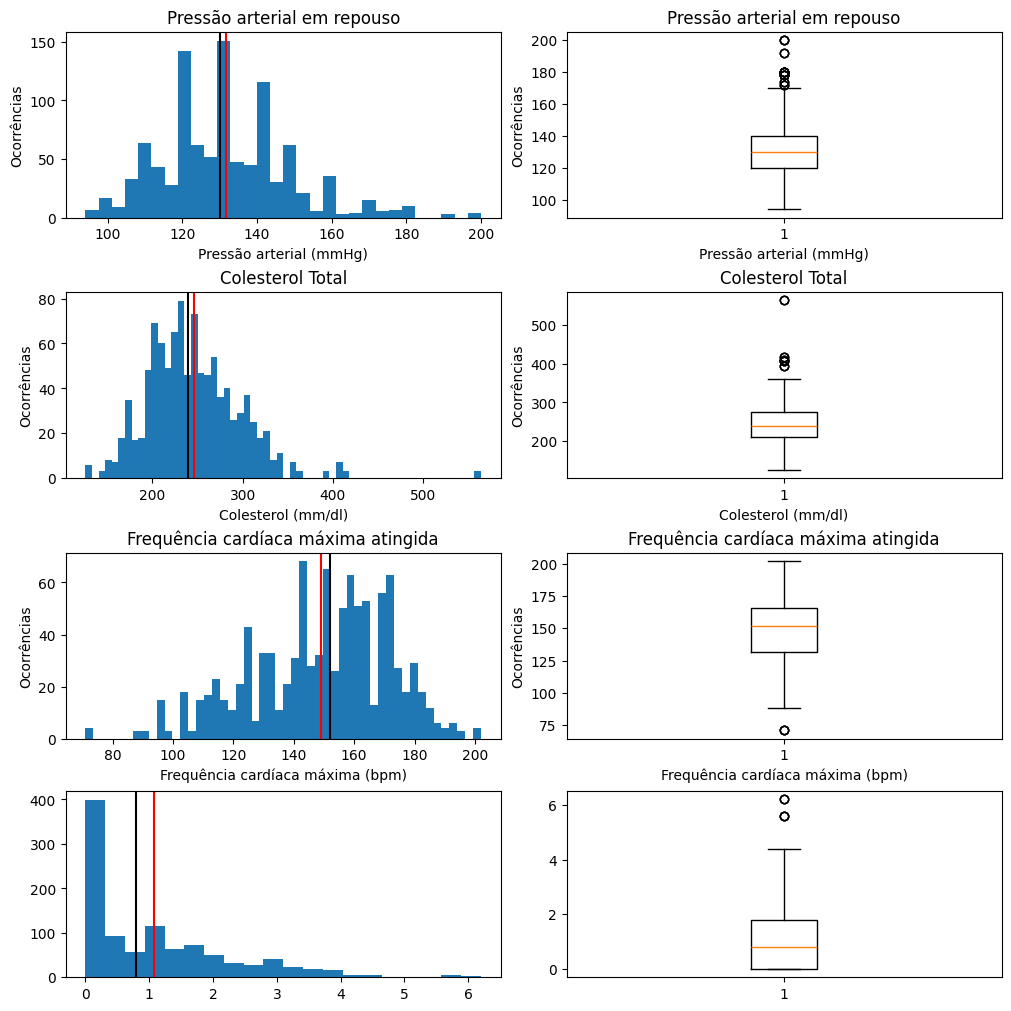

In [ ]:
def EDA_bool(df):
  """ Função que recebe um pd.Dataframe, e printa quantos valores tem
      cada coluna booleana"""
  print("Análise Exploratória: Dados Booleanos")
  for cols in cols_bool:
    print(df[cols].value_counts(), "\n")

def EDA_cat(df):
    """ Função que recebe um pd.Dataframe, e printa quantos valores tem
      cada coluna categórica em relativo ao total"""
    print("Análise Exploratória: Dados Categóricos")
    for cols in cols_cat:
      print(df[cols].value_counts(normalize=True), '\n')

def plot_graf(df):
  """ Função que faz o plot de todas as colunas numéricas"""

  print("Análise Exploratória: Dados Numéricos")
  fig, ax = plt.subplots(4,2, figsize=(10,10), layout="constrained")
  ax[0,0].hist(df['pressao_repouso'], bins=30)
  ax[0,0].axvline(df['pressao_repouso'].mean(), color='red')
  ax[0,0].axvline(df['pressao_repouso'].median(), color='black')
  ax[0,1].boxplot(df['pressao_repouso'])

  for axis in ax[0,:]:
    axis.set_title("Pressão arterial em repouso")
    axis.set_xlabel("Pressão arterial (mmHg)")
    axis.set_ylabel("Ocorrências")


  ax[1,0].hist(df['colesterol_total'], bins=60)
  ax[1,0].axvline(df['colesterol_total'].mean(), color='red')
  ax[1,0].axvline(df['colesterol_total'].median(), color='black')
  ax[1,1].boxplot(df['colesterol_total'])

  for axis in ax[1,:]:
    axis.set_title("Colesterol Total")
    axis.set_xlabel("Colesterol (mm/dl)")
    axis.set_ylabel("Ocorrências")

  ax[2,0].hist(df['freq_max'], bins=50)
  ax[2,0].axvline(df['freq_max'].mean(), color='red')
  ax[2,0].axvline(df['freq_max'].median(), color='black')
  ax[2,1].boxplot(df['freq_max'])

  for axis in ax[2,:]:
    axis.set_title("Frequência cardíaca máxima atingida")
    axis.set_xlabel("Frequência cardíaca máxima (bpm)")
    axis.set_ylabel("Ocorrências")

  ax[3,0].hist(df['depressao_st'], bins=20)
  ax[3,0].axvline(df['depressao_st'].mean(), color='red')
  ax[3,0].axvline(df['depressao_st'].median(), color='black')
  ax[3,1].boxplot(df['depressao_st'])

plt.show()


boolean = EDA_bool(df)
cat = EDA_cat(df)
graficos = plot_graf(df)


#### 2.3 - Limpeza dos dados (Cont. Questao 1 e 2)

##### Análise
 - Dados Categóricos: **Dropar linhas com as categorias inconscistentes, pois representam uma porcentagem muito pequena do total.**
    - ***vasos_coloridos***: Existe uma categoria (4) que representa **0,017%** do total.
    - ***talassemia***: Existe uma categoria (0) representado por **0,006%** do total.

- Dados Numéricos: **A estratégia vai ser remover os outliers usando os quantis**
  - Resultado :
    - Gráfico de Pressao Arterial tem **assimetria positiva** onde a maior concentração dos dados esta na esquerda
    - Gráfico de Colesterol tem **assimetria positiva** , pois tem uma maior inclinacao dos dados à direita
    - Gráfico de Frequencia Máxima tem **assimetria negativa**, pois os dados esta concentrados à direita ent tem maior inclinação à esquerda
    - Gráfico de Depressão do segmento ST tem **assimetria positiva**, pois a uma concentração muito grande de dados à esquerda

Limpando Dados Categóricos 

Análise Exploratória: Dados Categóricos
dor_no_peito
0    0.490
2    0.270
1    0.163
3    0.077
Name: proportion, dtype: float64 

ecg_repouso
1    0.494
0    0.491
2    0.015
Name: proportion, dtype: float64 

correlacao_st
1    0.471
2    0.455
0    0.074
Name: proportion, dtype: float64 

vasos_coloridos
0    0.571
1    0.226
2    0.134
3    0.069
Name: proportion, dtype: float64 

talassemia
2    0.533
3    0.403
1    0.064
Name: proportion, dtype: float64 

None
Limpando Dados Numéricos 

Análise Exploratória: Dados Numéricos


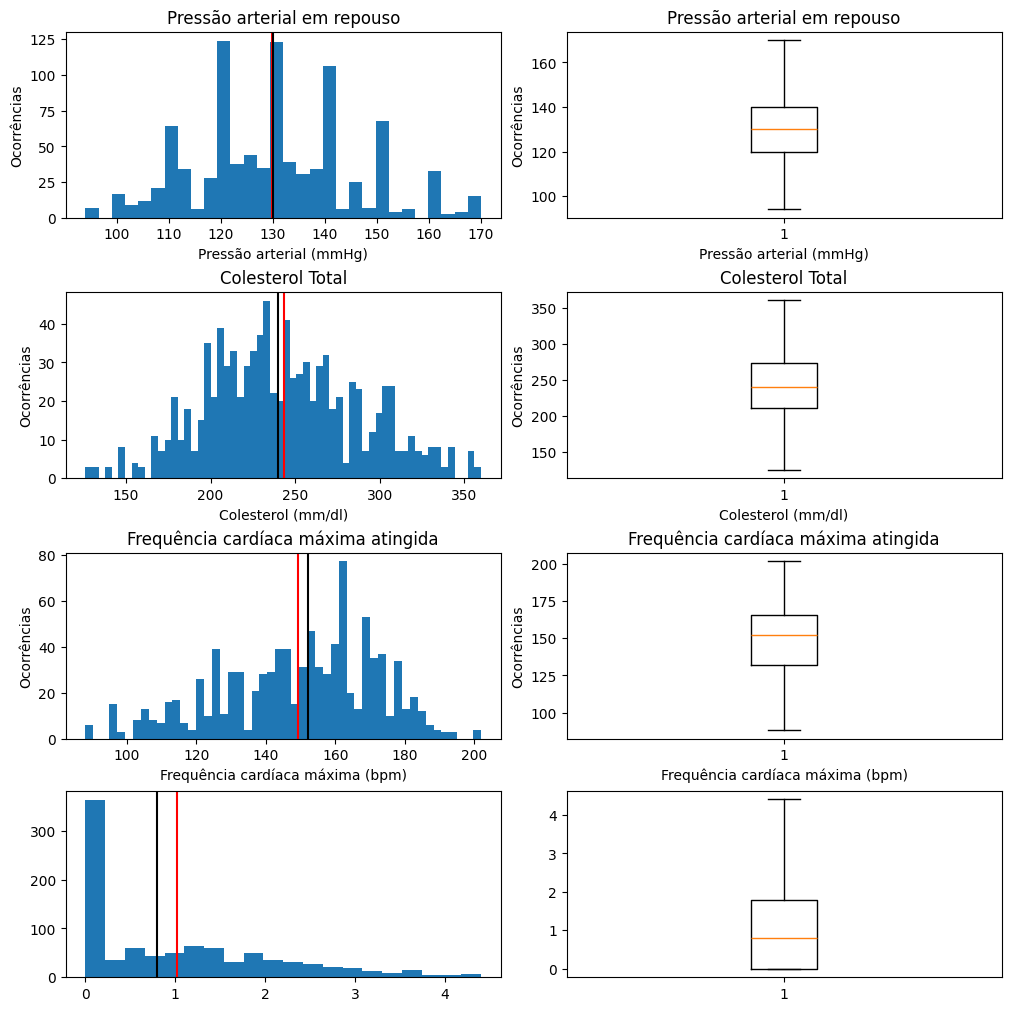

In [ ]:
def limpeza_cat(df):
  """ Função que recebe um pd.Dataframe e faz a limpeza removendo a categoria
      especificada como errada. A estratégia usada foi dropar direto os dados
      discrepantes, pois representam muito pouco do total"""

  print("Limpando Dados Categóricos \n")
  df['vasos_coloridos'] = df["vasos_coloridos"].cat.remove_categories([4])
  df['talassemia'] = df["talassemia"].cat.remove_categories([0]) # remove os valores mas deixa como NAs
  df = df.dropna() # entao tenho que dropar NAs
  print(EDA_cat(df))
  return df


def limpeza_numericos(df):
  """ Função que recebe um pd.Dataframe e faz a limpeza removendo os outliers
      a partir de quantis, metodologia mais usada para numericos"""
  #print(df.describe())
  print("Limpando Dados Numéricos \n")
  cols = ["pressao_repouso", "colesterol_total", "freq_max", "depressao_st"] # colunas numéricas

  for i, col in enumerate(cols):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    upper_limit = q3 + (1.5 * iqr)
    lower_limit = q1 - (1.5 * iqr)
    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

  return df


df = limpeza_cat(df)
df = limpeza_numericos(df)
plot_graf(df)

In [ ]:
df.head(100)

,idade,genero,dor_no_peito,pressao_repouso,colesterol_total,glicemia_alta,ecg_repouso,freq_max,angina_exerc,depressao_st,correlacao_st,vasos_coloridos,talassemia,diagnostico
0,52,True,0,125,212,False,1,168,False,1.0,2,2,3,False
1,53,True,0,140,203,True,0,155,True,3.1,0,0,3,False
2,70,True,0,145,174,False,1,125,True,2.6,0,0,3,False
3,61,True,0,148,203,False,1,161,False,0.0,2,1,3,False
4,62,False,0,138,294,True,1,106,False,1.9,1,3,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,52,True,3,118,186,False,0,190,False,0.0,1,0,1,True
105,47,True,0,110,275,False,0,118,True,1.0,1,1,2,False
106,51,True,0,140,299,False,1,173,True,1.6,2,0,3,False
107,62,True,1,120,281,False,0,103,False,1.4,1,1,3,False


### 3. Análises
Questões 3 e 4

#### Questão3 - Construa uma matriz de correlação. Quais variáveis têm maior associação com o diagnóstico de doença cardíaca?

As variáveis com maior correlação com o diagnóstico de doença cardiaca são:
1. Dor na região do peito (0.44)
2. Frequência Cardíaca Máxima (0.43)
3. Correlação do segmento ST (0.34)

Conclusão: Foi utilizado a correlação de spearman, pois eu achei que a correlação foi mais justa e pelo fato de ter muitos dados ordinarios e assimétricos no dataset.


dor_no_peito        0.441711
freq_max            0.434668
correlacao_st       0.348772
ecg_repouso         0.158930
glicemia_alta      -0.012543
pressao_repouso    -0.097442
colesterol_total   -0.129700
idade              -0.243232
genero             -0.326382
talassemia         -0.407878
angina_exerc       -0.420577
depressao_st       -0.433868
vasos_coloridos    -0.505898
dtype: float64


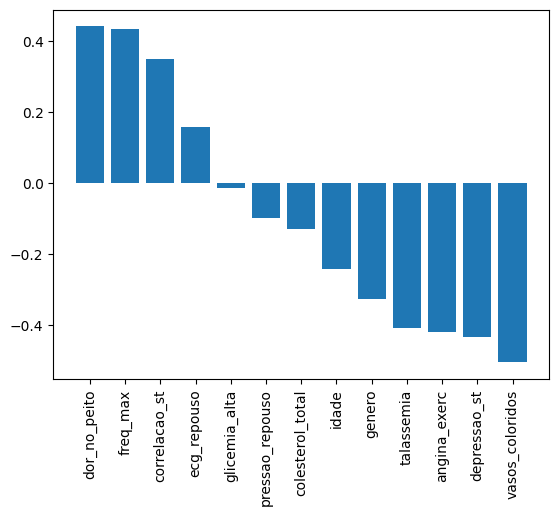

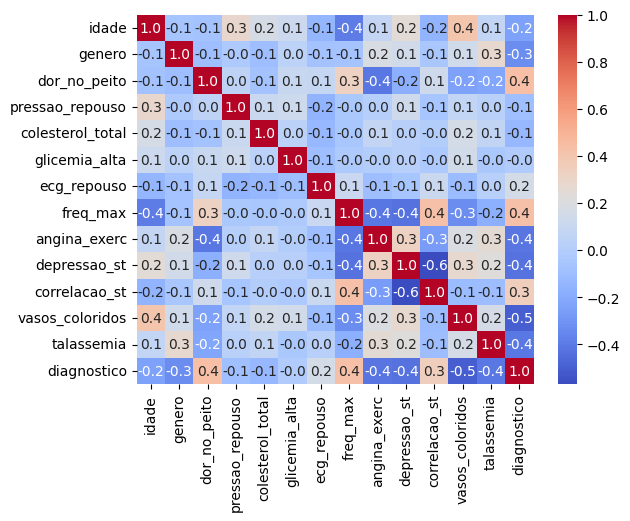

In [ ]:
X = df.drop(columns='diagnostico')
y = df['diagnostico'] == True

matriz_corr = X.corrwith(y, method='spearman').sort_values(ascending=False)
print(matriz_corr)

plt.bar(matriz_corr.index, matriz_corr.values)
plt.xticks(rotation=90)
plt.show()

sns.heatmap(df.corr(method='spearman'), annot=True, cmap='coolwarm', fmt='.1f')
plt.show()


#### Questão 4 - Compare a distribuição de colesterol e pressão arterial entre os grupos com e sem doença. Use testes estatísticos para validar as diferenças.



Conclusão: De acordo com a análise dos gráficos, conseguimos ver que grupo do colesterol tende a ser uma distruibuição normal, porque no histograma podemos ver o formato da densidade e também no qqplot conseguimos ver que os dados seguem a linha linear. Porém, analisando o grupo da pressão arterial, conseguimos ver o oposto, uma não normalidade, pois nos gráficos mostram que a densidade não seguem uma curva gaussiana e no qqplot a concentração dos dados não estão seguindo a linha linear.

- Colesterol: Metodos com Testes Paramêtricos
- Pressão: Métodos não Paramêtricos


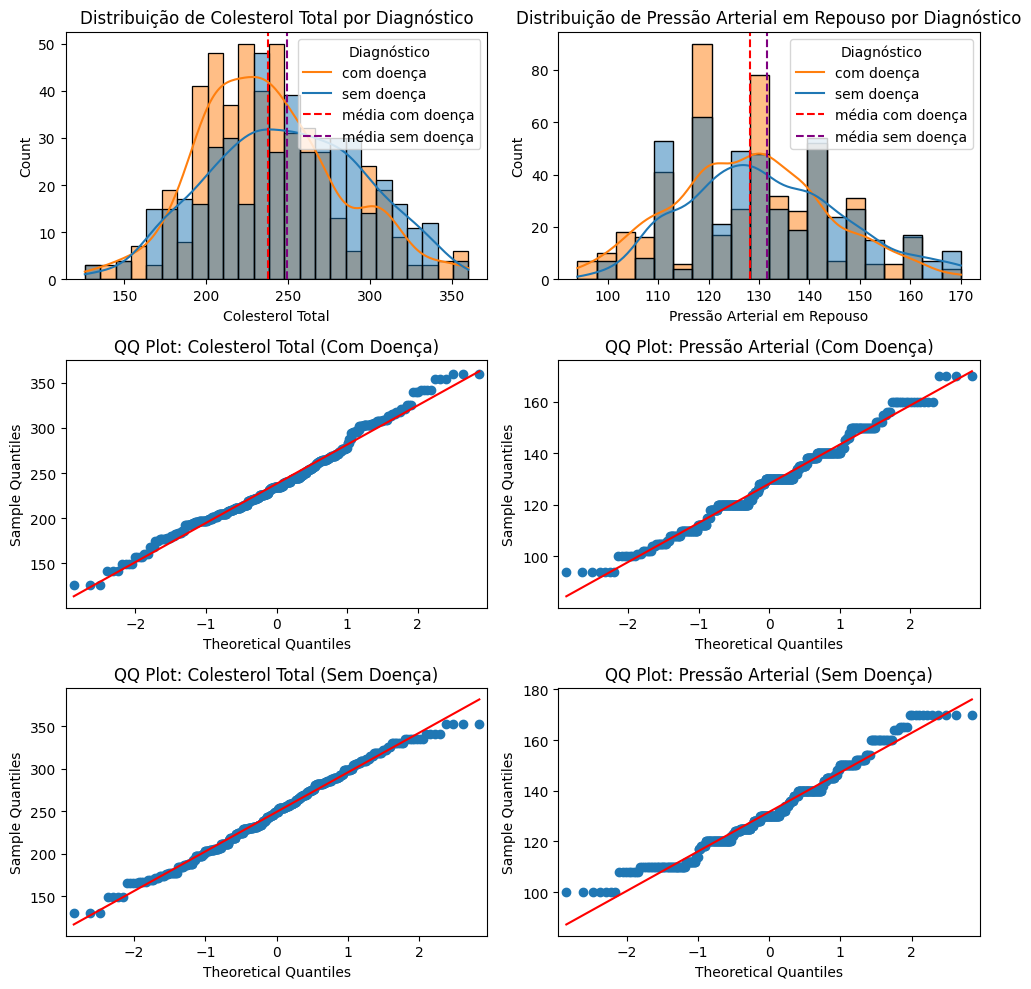

In [ ]:
diagnostico_1 = df.loc[df['diagnostico'] == 1]
diagnostico_0 = df.loc[df['diagnostico'] == 0]

cols = ['colesterol_total', 'pressao_repouso']

plt.figure(figsize=(10, 10))

plt.subplot(3, 2, 1)
sns.histplot(df, x='colesterol_total', hue='diagnostico', kde=True, bins=25)
plt.axvline(diagnostico_1['colesterol_total'].mean(), color='red', linestyle='--')
plt.axvline(diagnostico_0['colesterol_total'].mean(), color='purple', linestyle='--')
plt.title('Distribuição de Colesterol Total por Diagnóstico')
plt.xlabel('Colesterol Total')
plt.legend(title="Diagnóstico", labels=['com doença', 'sem doença', 'média com doença','média sem doença'], loc='upper right')

plt.subplot(3, 2, 2)
sns.histplot(df, x='pressao_repouso', hue='diagnostico', kde=True, bins=20)
plt.axvline(diagnostico_1['pressao_repouso'].mean(), color='red', linestyle='--')
plt.axvline(diagnostico_0['pressao_repouso'].mean(), color='purple', linestyle='--')
plt.title('Distribuição de Pressão Arterial em Repouso por Diagnóstico')
plt.xlabel('Pressão Arterial em Repouso')
plt.legend(title="Diagnóstico", labels=['com doença', 'sem doença', 'média com doença','média sem doença'], loc='upper right')

ax3 = plt.subplot(3, 2, 3)
sm.qqplot(diagnostico_1['colesterol_total'], line='s', ax=ax3)
ax3.set_title('QQ Plot: Colesterol Total (Com Doença)')

ax4 = plt.subplot(3, 2, 4)
sm.qqplot(diagnostico_1['pressao_repouso'], line='s', ax=ax4)
ax4.set_title('QQ Plot: Pressão Arterial (Com Doença)')

ax5 = plt.subplot(3, 2, 5)
sm.qqplot(diagnostico_0['colesterol_total'], line='s', ax=ax5)
ax5.set_title('QQ Plot: Colesterol Total (Sem Doença)')

ax6 = plt.subplot(3, 2, 6)
sm.qqplot(diagnostico_0['pressao_repouso'], line='s', ax=ax6)
ax6.set_title('QQ Plot: Pressão Arterial (Sem Doença)')

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

In [ ]:
# Testes Paramêtricos
# Hipotese 0 : as médias dos dois grupos são iguais
# Hipotese 1: as médias dos dois grupos são diferentes
# Se p_t < 0.05 : as médias são diferentes
# Se p_t > 0.05 : as médias são iguais
colesterol_1 = diagnostico_1['colesterol_total']
colesterol_0 = diagnostico_0['colesterol_total']

stats_levene, p_levene = stats.levene(colesterol_0, colesterol_1)
stats_t, p_t = stats.ttest_ind(colesterol_0, colesterol_1, equal_var=(p_levene> 0.05))
print(f'Colesterol X Diagnostico \nEstast. : {stats_t:.3f}, p-valor : {p_t:.4f}')
if p_t < 0.05:
  print("As médias dos grupos são diferentes \n")
else :
  print("As médias são iguais \n")

# Testes Não Paramêtricos
# Hipotese 0 : as médias dos dois grupos são iguais
# Hipotese 1: as médias dos dois grupos são diferentes

pressao_1 = diagnostico_1['pressao_repouso']
pressao_0 = diagnostico_0['pressao_repouso']

stats_u, p_u = stats.mannwhitneyu(pressao_0, pressao_1, alternative='two-sided')
print(f'Pressão X Diagnostico \nEstast. : {stats_u}, p-valor : {p_u:.4f}')
if p_u < 0.05:
  print("As médias dos grupos são diferentes \n")
else:
  print("As médias são iguais \n")

Colesterol X Diagnostico 
Estast. : 3.787, p-valor : 0.0002
As médias dos grupos são diferentes 

Pressão X Diagnostico 
Estast. : 123442.5, p-valor : 0.0028
As médias dos grupos são diferentes 



### 4. Modelos

#### Questao 5 - Treine um modelo de Random Forest. Avalie com acurácia, precisão, recall e F1-score. Justifique a escolha da métrica principal.
- Passos:
1. Definir X e y e dividir em train/test
2. Criar o obj RF e treinar o modelo (max_feature - melhor com $ \sqrt n$)
3. Mostrar as Métricas - qual é a principal ?

Metrica Principal: **Recall** ,pois eu quero minimizar ao máximo os falsos negativos, para nao indicar incorretamente a ausência da doença cardíaca. Recall = 0.94%

In [ ]:
X = df.drop("diagnostico", axis=1)
y = df["diagnostico"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RF(max_features='sqrt', n_estimators=500, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print('\n------------')
print(classification_report(y_test, y_pred))

# Principais variáveis que pesaram no modelo
print('Variáveis que mais pesaram no modelo')

for score, name in zip(rf.feature_importances_, df.columns):
  print(name, round(score,2))

rf_metrics = classification_report(y_test, y_pred, output_dict=True) # criar a tabela da Q9

[[123   0]
 [  9 151]]

------------
              precision    recall  f1-score   support

       False       0.93      1.00      0.96       123
        True       1.00      0.94      0.97       160

    accuracy                           0.97       283
   macro avg       0.97      0.97      0.97       283
weighted avg       0.97      0.97      0.97       283

Variáveis que mais pesaram no modelo
idade 0.09
genero 0.04
dor_no_peito 0.13
pressao_repouso 0.06
colesterol_total 0.08
glicemia_alta 0.01
ecg_repouso 0.02
freq_max 0.12
angina_exerc 0.04
depressao_st 0.1
correlacao_st 0.06
vasos_coloridos 0.14
talassemia 0.1


#### Questão 6 - Aplique feature engineering: crie faixas etárias, interações entre variáveis e normalize os dados. Como isso impacta o desempenho do modelo?

- Passos
1. Criar Faixas Etárias
2. Dependências entre variáveis
   - Depressao ST X Correlação ST X Frequência Cardíaca
   - Frequência Cardíaca X Angina no Exercício
   - Frequência Cardiáca X Idade
   - Angina X Dor no Peito
   - Vasos Coloridos X Idade
   - Dor no Peito X Frequência Cardiáca
3. Normalizar (StandarScaler)

- Conclusão: Transformações de feature engineering em Random Forest não tem um impacto muito grande, visto que esse modelo estatístico lida muito bem com redundância de dados e nao se importam com escalas e normalizações.

In [ ]:
#1.
df_t = df.copy()
df_t['faixa_etaria'] = pd.cut(df_t['idade'], bins=[0,12,18,60,df_t['idade'].max()], labels=[0,1,2,3], ordered=True).astype('category')

#2. Descobrir quais são as combinações de variáveis que tem mais correlações

print("Dependências entre Variáveis:")
corr = df.corr().abs().unstack().sort_values(ascending=False)
corr = corr[(corr > 0.3) & (corr < 1)]
corr.drop_duplicates(inplace=True)
print(corr, '\n')

#df_t['idade_colesterol'] = df_['idade'] * df_t['colesterol_total]
#df_t['idade_pressao'] = df_['idade'] * df_t['pressao_repouso]
#df_t['idade_glicemia'] = df_['idade'] * df_t['glicemia_alta]
df_t['dep_corr_freq'] = df_t['correlacao_st'].astype(float) * df_t['depressao_st'] * df_t['freq_max']
df_t['freq_ang'] = df_t['freq_max'] * df_t['angina_exerc']
df_t['freq_idade'] = df_t['freq_max'] * df_t['idade']
df_t['ang_dor_peito'] = df_t['angina_exerc'] * df_t['dor_no_peito'].astype(int)
df_t['vasos_idade'] = df_t['vasos_coloridos'].astype(int) * df_t['idade']
df_t['dor_freq'] = df_t['dor_no_peito'].astype(int) * df_t['freq_max']

#3. Normalizar somente os numéricos
X = df_t.drop("diagnostico", axis=1).values
y = df_t["diagnostico"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler =  StandardScaler()
if X_train.dtype in ['int64', 'float64']:
  X_train = scaler.fit_transform(X_train)
  X_test = scaler.transform(X_test)

rf = RF(max_features='sqrt', n_estimators=500, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print('\n------------')
print(classification_report(y_test, y_pred))

Dependências entre Variáveis:
correlacao_st    depressao_st       0.534227
vasos_coloridos  diagnostico        0.470918
depressao_st     diagnostico        0.446740
freq_max         diagnostico        0.431726
angina_exerc     diagnostico        0.420577
diagnostico      dor_no_peito       0.410372
freq_max         angina_exerc       0.400090
idade            freq_max           0.397991
correlacao_st    freq_max           0.389020
angina_exerc     dor_no_peito       0.385724
idade            vasos_coloridos    0.380553
talassemia       diagnostico        0.360329
depressao_st     freq_max           0.354345
angina_exerc     depressao_st       0.333803
diagnostico      genero             0.326382
                 correlacao_st      0.325151
freq_max         vasos_coloridos    0.311291
dor_no_peito     freq_max           0.301788
dtype: float64 

[[123   0]
 [  3 157]]

------------
              precision    recall  f1-score   support

       False       0.98      1.00      0.99       1

#### Questao 7 - Use um modelo de regressão logística e interprete os coeficientes. Quais variáveis aumentam ou reduzem o risco de doença?
As variáveis que tem maior relação com o risco de doenças cardíacas no modelo são:
1. Gênero
2. Vasos Coloridos
3. Talassemia


As variáveis que tem a menor relação com o risco de doenças cardíacas no modelo são:
1. Colesterol Total
2. Pressão Arterial em Repouso
3. Idade

In [ ]:
X = df_t.drop("diagnostico", axis=1)
y = df_t["diagnostico"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lr = LR(max_iter=2000, solver='liblinear')
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

lr_df = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': np.abs(lr.coef_[0])
}).sort_values(by='Coeficiente', ascending=False)

lr_metrics = classification_report(y_test, y_pred, output_dict=True) # criar a tabela da Q9
print(lr_df)

[[105  18]
 [ 14 146]]
              precision    recall  f1-score   support

       False       0.88      0.85      0.87       123
        True       0.89      0.91      0.90       160

    accuracy                           0.89       283
   macro avg       0.89      0.88      0.88       283
weighted avg       0.89      0.89      0.89       283

            Variável  Coeficiente
1             genero     1.892942
9       depressao_st     1.425947
12        talassemia     1.236504
10     correlacao_st     0.437849
11   vasos_coloridos     0.348866
5      glicemia_alta     0.333202
6        ecg_repouso     0.328793
2       dor_no_peito     0.293786
17     ang_dor_peito     0.187389
0              idade     0.157544
8       angina_exerc     0.156702
7           freq_max     0.058594
13      faixa_etaria     0.032857
18       vasos_idade     0.022263
3    pressao_repouso     0.019263
4   colesterol_total     0.010827
19          dor_freq     0.006395
14     dep_corr_freq     0.004337
15  

#### Questão 8 - Gere um gráfico de feature importance para explicar as predições do modelo. Quais variáveis mais influenciam o resultado?
- Gênero
- Vasos Coloridos
- Talassemia

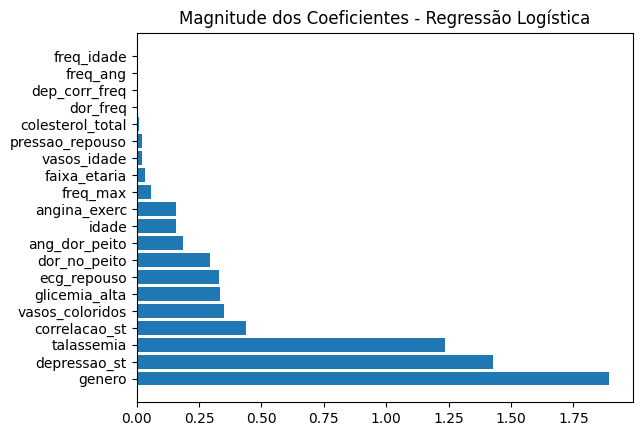

In [ ]:
plt.barh(lr_df['Variável'], lr_df['Coeficiente'])
plt.title("Magnitude dos Coeficientes - Regressão Logística")
plt.show()

#### Questão 9 - Compare o desempenho de pelo menos 3 algoritmos diferentes. Construa uma tabela comparativa e justifique qual você recomendaria para uso clínico
RNAs : Perceptron simples com 3 camadas (2 densas escondidas e o output)

- Problemas: Conversão de dados nao numericos em numéricos

In [ ]:
X_df = df_t.drop("diagnostico", axis=1).copy()
y = df_t["diagnostico"].astype(int).values

bool_cols = X_df.select_dtypes(include=['bool']).columns
X_df[bool_cols] = X_df[bool_cols].astype(int)

cat_cols = X_df.select_dtypes(include=['category']).columns
X_df = pd.get_dummies(X_df, columns=cat_cols, drop_first=True)

X = X_df.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

rna = model.fit(X_train_scaled, y_train, epochs=50, batch_size=16, validation_split=0.2, callbacks=[early_stop])


Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6307 - loss: 0.6442 - val_accuracy: 0.7576 - val_loss: 0.5107
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7424 - loss: 0.5143 - val_accuracy: 0.7955 - val_loss: 0.4392
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8163 - loss: 0.4326 - val_accuracy: 0.8030 - val_loss: 0.3979
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8258 - loss: 0.3910 - val_accuracy: 0.8258 - val_loss: 0.3662
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8485 - loss: 0.3588 - val_accuracy: 0.8333 - val_loss: 0.3485
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8333 - loss: 0.3531 - val_accuracy: 0.8561 - val_loss: 0.3300
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8580 - loss: 0.3540 - val_accuracy: 0.8561 - val_loss: 0.3174
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8693 - loss: 0.3181 - val_accuracy: 0.8561 - val_loss:

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


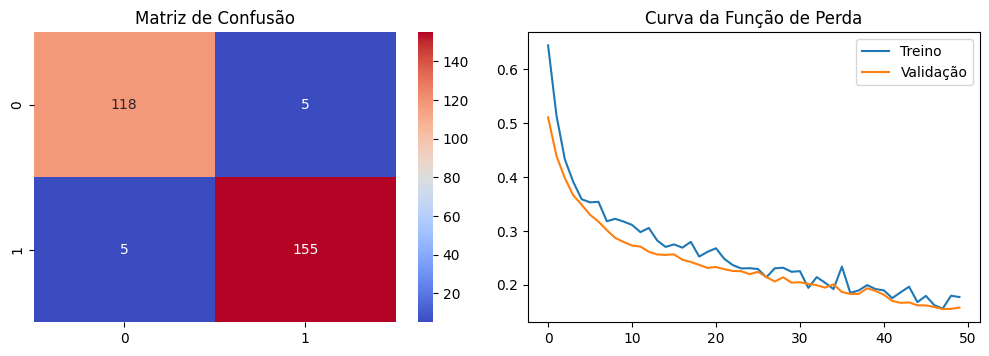

In [ ]:
y_pred = model.predict(X_test_scaled)
y_pred = (y_pred > 0.5).astype(int)

plt.figure(figsize=(10, 10))

plt.subplot(3, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='coolwarm')
plt.title('Matriz de Confusão')

plt.subplot(3, 2, 2)
plt.plot(rna.history['loss'])
plt.plot(rna.history['val_loss'])
plt.legend(labels=["Treino", "Validação"])
plt.title('Curva da Função de Perda')

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

#### Conclusão Questao 9
A principal métrica que tem que ser levada em análises de saúdes é o Recall, porque nós temos que minimizar o máximo os falsos negativos, ou seja, o modelo tem que acertar corretamente as pessoas que foram diagnosticadas com a doença, para que em um caso real, não perca nenhum paciente com sintomas reais da doença. Importante ressaltar a métrica F1-score,o equilibrio entre o recall e a precisão, que para nosso caso é sempre importante acertar os positivos.

In [ ]:
rna_metrics = classification_report(y_test, y_pred, output_dict=True)
print(rna_metrics)

tabela_comparativa = pd.DataFrame({
    "Acurácia" : [round(rf_metrics['accuracy'],2), round(lr_metrics['accuracy'],2), round(rna_metrics['accuracy'],2)],
    "Precisão" : [round(rf_metrics['True']['precision'],2), round(lr_metrics['True']['precision'],2), round(rna_metrics['1']['precision'],2)],
    "Recall" : [round(rf_metrics['True']['recall'],2), round(lr_metrics['True']['recall'],2), round(rna_metrics['1']['recall'],2)],
    "F1-Score" : [round(rf_metrics['True']['f1-score'],2), round(lr_metrics['True']['f1-score'],2), round(rna_metrics['1']['f1-score'],2)]
}, index = ["Random Forest", "Regressão Logística", "Redes Neurais Artificiais"])

tabela_comparativa

{'0': {'precision': 0.959349593495935, 'recall': 0.959349593495935, 'f1-score': 0.959349593495935, 'support': 123.0}, '1': {'precision': 0.96875, 'recall': 0.96875, 'f1-score': 0.96875, 'support': 160.0}, 'accuracy': 0.9646643109540636, 'macro avg': {'precision': 0.9640497967479675, 'recall': 0.9640497967479675, 'f1-score': 0.9640497967479675, 'support': 283.0}, 'weighted avg': {'precision': 0.9646643109540636, 'recall': 0.9646643109540636, 'f1-score': 0.9646643109540636, 'support': 283.0}}


,Acurácia,Precisão,Recall,F1-Score
Random Forest,0.97,1.00,0.94,0.97
Regressão Logística,0.89,0.89,0.91,0.90
Redes Neurais Artificiais,0.96,0.97,0.97,0.97


### CONCLUSÃO FINAL DO TRABALHO
- Dificuldades:
  - Conversão de dados nao numericos em numéricos para treinar o modelo. Dados booleanos é facil a conversão, os dados categóricos foi usado o One-Hot, onde eu nao lembrava como usava no pandas
  - Overfitting no treinamento, a solução foi usar um dropout de 20% e o early_stop só para agilizar.
  - Entendimento da Questão 4. Não sabia o que tinha que fazer
- Mudanças durante o trabalho: Eu tinha pensado em fazer o feature engineering combinando a idade com outros atributos, pelo fato, da achar que a idade impactaria no resultado final da doença. Mas, fiz uma mudança de ver quais variáveis mais se correlacionam entre elas (sem contar com o outcome) por meio da função de correlação, e junta-las em uma coluna. Outro Aspecto na mesma questão foi, se eu deixaria as colunas unitárias que foram combinadas ainda presentes na tabela, e decidi mante-las.
- Uso da IA: Nesse trabalho, utilizei a IA estratégicamente para ter um entendimento mais rico da área da saúde sobre os atributos dos dados Heart Disease, além de ser auxiliado em funções (levene, mannwhitneyu,StandarScaler,get_dummies, EarlyStopping),parâmetros de plot e hiperparametros de modelos e para o entendimento estatistico da questão 4.